In [ ]:
import math 
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
def f(x):
    return 3*x**2 - 4*x + 5


In [ ]:
f(3.0)

In [ ]:
x_axis = np.arange(-5, 5, 0.25)
y_axis = f(x_axis)
plt.plot(x_axis, y_axis)



In [ ]:
h=0.00000001
x=2/3
(f(x+h) -f(x))/h

In [ ]:
a = 2.0
b = -3.0
c =  10.0

d= a*b +c 

print(d)


In [ ]:
h =0.0001
a = 2.0
b = -3.0
c =  10.0

# we want to compute the slope of d with respect to c,a,b
d1 = a*b +c
c += h   
d2 = a*b +c

print('d1',d1)
print('d2',d2)
print('slope', (d2-d1)/h)



In [ ]:
class Value:
    def __init__(self ,data , _children=() , _op='', _label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self._label = _label

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        out =  Value(self.data + other.data, (self , other), _op='+')
        def _backward():
            self.grad += 1* out.grad
            other.grad += 1* out.grad
        out._backward = _backward   
            

        return out

    def __mul__(self, other):
        out = Value(self.data * other.data, (self , other), _op='*')
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out

    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ), _op='exp')
        def _backward():
            self.grad = out.grad * out.data
        out._backward = _backward
        return out
    
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) -1)/(math.exp(2*x) +1)
        out = Value(t, (self, ), _op='tanh')
        def _backward():
            self.grad = (1 - t**2) * out.grad
        out._backward = _backward
        return out


a= Value(2.0 , _label='a')
b= Value(-3.0 , _label='b')
c= Value(10.0 , _label='c')
e = a*b  ; e._label = 'e'
d = e + c ; d._label = 'd'
f= Value(-2.0 , _label='f')
L = d*f ; L._label = 'L'






In [ ]:
d._prev 

In [ ]:
#visualize the nodes and the source for understanding 
from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})  # LR = left to right
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        dot.node(name=uid, label="{ %s | data %.4f | grad %.4f }" % (n._label, n.data, n.grad), shape='record')
        if n._op:
            dot.node(name =uid + n._op, label=n._op)
            dot.edge(uid + n._op, uid)    
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    return dot

In [ ]:
draw_dot(L)

In [ ]:
L = d*f 
dL/ dd = f 
dL/ df = d
d = c+ e 

e= a*b 

dl / de = dl / dd * dd / de * de/ da 
de / da  

dd / dc = 1.0
dd / de = 1.0

dL / dd , dd / dc  

In [ ]:
f.grad = 4.0 
d.grad = -2.0 
e.grad = -2.0 
c.grad = -2.0
a.grad = 6
b.grad = -4

In [ ]:
L.grad = 1.0

In [ ]:
# function to test the slope of L with respect to a,b,c,f
def _try():

    h =0.001
    a= Value(2.0 , _label='a')
    b= Value(-3.0 , _label='b')
    c= Value(10.0 , _label='c')
    e = a*b  ; e._label = 'e'
    d = e + c ; d._label = 'd'
    f= Value(-2.0 , _label='f')
    L = d*f ; L._label = 'L'
    L1 = L.data

    a= Value(2.0  , _label='a')
    b= Value(-3.0 , _label='b')
    c= Value(10.0 , _label='c')
    e = a*b  ; e._label = 'e'
    d = e + c ; d._label = 'd'
    f= Value(-2.0 , _label='f')
    L = d*f ; L._label = 'L'
    L2 = L.data + h
    print((L2 - L1)/h)

_try()

In [98]:
# bulid a simple neural network from scratch using the Value class and backpropagation to compute gradients.

x1 = Value(2.0 , _label='x1')
x2  = Value(0.0 , _label='x2')

w1 = Value(-3.0 , _label='w1')
w2 = Value(1.0 , _label='w2')

b = Value(6.7 , _label='b')

x1w1 = x1*w1 ; x1w1._label = 'x1w1'
x2w2 = x2*w2 ; x2w2._label = 'x2w2'
c = x1w1 + x2w2 ; c._label = 'c'
n = c + b ; n._label = 'n'
out = n.tanh() ; out._label = 'out'



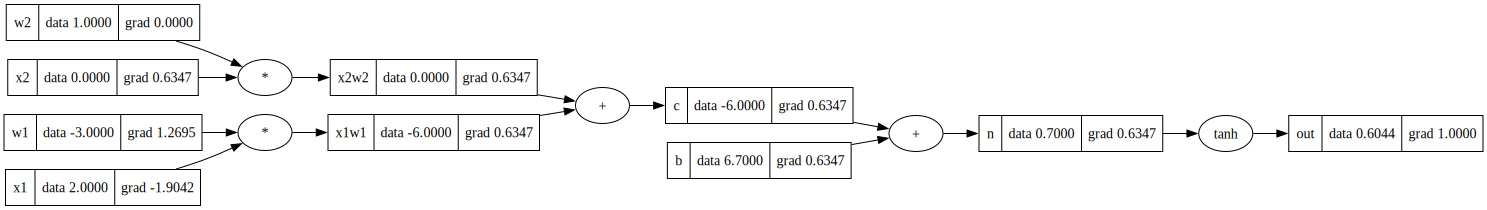

In [102]:
draw_dot(out)

In [103]:
# calculate the gradients using backpropagation on topo list 
out. grad = 1.0

topo = []
visited = set()
def build_topo(v):
    if v not in visited: 
        visited.add(v)
        for child in v._prev:
            build_topo(child)
        topo.append(v)
build_topo(out)

for node in reversed(topo):
    node._backward()